In [10]:

import torch
print(torch.cuda.is_available())


from detecto import core, utils, visualize
# from detecto.visualize import show_labeled_image, plot_prediction_grid
# from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import glob
# import re
# import os




from detecto import core, utils, visualize
from detecto.visualize import show_labeled_image, plot_prediction_grid
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import re
import os
import gc


# Set the maximum number of rows and columns to display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)


True


In [2]:
file_path = '/home/ht21074/Auto_box_apples/Auto_box_apples/Source_folder/csv_files/All_data_csv/'

# load csv files
data_NZ2023_a_na = pd.read_csv(f'{file_path}data_NZ2023_a_na.csv')
data_NZ2023_b_na = pd.read_csv(f'{file_path}data_NZ2023_b_na.csv')
data_NZ2023_c_na = pd.read_csv(f'{file_path}data_NZ2023_c_na.csv')
data_NZ2023_d_na = pd.read_csv(f'{file_path}data_NZ2023_d_na.csv')
data_NZ2024_a_na = pd.read_csv(f'{file_path}data_NZ2024_a_na.csv')
data_NZ2024_b_na = pd.read_csv(f'{file_path}data_NZ2024_b_na.csv')
data_NZ2024_c_na = pd.read_csv(f'{file_path}data_NZ2024_c_na.csv')
data_NZ2024_d_na = pd.read_csv(f'{file_path}data_NZ2024_d_na.csv')
data_UK2024_a_na = pd.read_csv(f'{file_path}data_UK2024_a_na.csv')
data_UK2024_b_na = pd.read_csv(f'{file_path}data_UK2024_b_na.csv')
data_UK2024_c_na = pd.read_csv(f'{file_path}data_UK2024_c_na.csv')
data_UK2024_d_na = pd.read_csv(f'{file_path}data_UK2024_d_na.csv')

In [12]:
# Load model trained which we annotated to detect apples in rgb images using MAKESENSE.AI
model2 = core.Model.load("/media/data/model_weights.pth",['Apple'])

/home/ht21074/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ht21074/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
# Spectral folder

# Split by '/' and remove last split in string

data_NZ2023_a_na['Spectral_folder_a'] = data_NZ2023_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_NZ2023_b_na['Spectral_folder_b'] = data_NZ2023_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_NZ2023_c_na['Spectral_folder_c'] = data_NZ2023_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_NZ2023_d_na['Spectral_folder_d'] = data_NZ2023_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')
data_NZ2024_a_na['Spectral_folder_a'] = data_NZ2024_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_NZ2024_b_na['Spectral_folder_b'] = data_NZ2024_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_NZ2024_c_na['Spectral_folder_c'] = data_NZ2024_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_NZ2024_d_na['Spectral_folder_d'] = data_NZ2024_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')
data_UK2024_a_na['Spectral_folder_a'] = data_UK2024_a_na['Image_folder_A'].str.split('/').str[:-1].str.join('/')
data_UK2024_b_na['Spectral_folder_b'] = data_UK2024_b_na['Image_folder_B'].str.split('/').str[:-1].str.join('/')
data_UK2024_c_na['Spectral_folder_c'] = data_UK2024_c_na['Image_folder_C'].str.split('/').str[:-1].str.join('/')
data_UK2024_d_na['Spectral_folder_d'] = data_UK2024_d_na['Image_folder_D'].str.split('/').str[:-1].str.join('/')


In [74]:
test_data = data_NZ2024_a_na[5:15]
print(test_data)



                                     Image_folder_A    image_filename_A  \
5   20240307 Gala/2024-03-07_001/2024-03-07_001.png  2024-03-07_001.png   
6   20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
7   20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
8   20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
9   20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
10  20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
11  20240307 Gala/2024-03-07_005/2024-03-07_005.png  2024-03-07_005.png   
12  20240307 Gala/2024-03-07_009/2024-03-07_009.png  2024-03-07_009.png   
13  20240307 Gala/2024-03-07_009/2024-03-07_009.png  2024-03-07_009.png   
14  20240307 Gala/2024-03-07_009/2024-03-07_009.png  2024-03-07_009.png   

         ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
5    Gala_6       6       7.36       7.07  11.49      20      9.0  5.651436   
6    Gala_7     

In [127]:
# This extracts the coordinates of the bounding boxes for each apple for each image

c = 0
thresh = 0.8

# image_name is the image_file_name in the csv file
# loc_link is the folder location of the image 

def extractor(image_name, model, loc_link):
    global c

    c += 1
    print(c)
    folder_link = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/"
    folder_link = folder_link
        
    # image_link = folder_link + image_name
    

    image_link = folder_link + loc_link + '/' 
    image_link_path = image_link + image_name

    # print(image_link_path)
    
    # image = utils.read_image(image_link)


    # image_path = os.path(image_link_path)
    image = utils.read_image(image_link_path)

    predictions = model.predict(image)
    labels, boxes, scores = predictions
    # show_labeled_image(image, boxes, labels)

    filtered_indices = np.where(scores > thresh)
    filtered_scores = scores[filtered_indices]
    filtered_boxes = boxes[filtered_indices]
    num_list = filtered_indices[0].tolist()
    filtered_labels = [labels[i] for i in num_list]
    # show_labeled_image(image, filtered_boxes, filtered_labels)

    # tenosrs are sorted on their y position  - e.g they are sorted from top to bottom
    sorted_tensor = filtered_boxes[np.lexsort((filtered_boxes[:, 1],))]

    # for when there are odd number of apples (boxes) and more than 3 apples
    if len(filtered_boxes) > 3 and len(filtered_boxes) % 2 == 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2)

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][
                        np.lexsort((sorted_tensor[i : i + num_rows, 0],))
                    ]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )
    # for when there are even number of apples (boxes) and more than 3 apples
    elif len(filtered_boxes) > 3 and len(filtered_boxes) % 2 != 0:

        # Determine the number of rows in the sorted tensor
        num_rows = int(len(sorted_tensor) / 2) + 1

        # Sort each row from left to right (based on xmin)
        sorted_tensor = torch.tensor(
            np.concatenate(
                [
                    sorted_tensor[i : i + num_rows, :][np.lexsort((sorted_tensor[i : i + num_rows, 0],))]
                    for i in range(0, len(sorted_tensor), num_rows)
                ]
            )
        )

    # for when there are less than 4 apples
    elif len(filtered_boxes) < 4:

        coordinates = [(box[0], box[1], box[2], box[3]) for box in filtered_boxes]

        # Step 2: Calculate center points
        center_points = [
            (0.5 * (x1 + x2), 0.5 * (y1 + y2)) for (x1, y1, x2, y2) in coordinates
        ]

        # Step 3: Sort bounding boxes based on x-coordinate of center point
        sorted_indices = sorted(
            range(len(center_points)), key=lambda k: center_points[k][0]
        )
        sorted_coordinates = [coordinates[i] for i in sorted_indices]

        # Step 4: Update the original tensor list
        sorted_tensor = [torch.tensor(coord) for coord in sorted_coordinates]

    return sorted_tensor

In [ ]:
# This extracts the coordinates of the bounding boxes for each apple for each image using reconstructed rgb
  
# NZ2023_loc_link = 'spectral_NZ_2023'
# NZ2024_loc_link = 'spectral_NZ_2024'
# UK2024_loc_link = 'spectral_UK_2024'

# # image_name  = test_data["Spectral_folder_a"]
# loc_link =NZ2023_loc_link

c = 0
thresh = 0.8

height = 512
width = 512
# bands = len(spectral_data) // (height * width) # 204
bands = 204

# df is the name of the csv file
# loc_link is the folder location of the image 

def extractor(df, model, loc_link, side):
    global c

    
    c += 1
    print(c)
    folder_link = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/"
        

    all_tensors = [] 
    for index, row in df.iterrows():
        image_link = folder_link + loc_link + '/' 
        image_link_path = image_link + row[f'Spectral_folder_{side}'] + '/results/' 
        dat_files = glob.glob(f"{image_link_path}*.dat")
    
        if not dat_files:
                print(f"No .dat file found in {image_link_path}. Skipping...")
                continue
        
        # load .dat_file      
            
        spectral_data = np.fromfile(dat_files[0], dtype=np.float32)
        bands = len(spectral_data) // (height * width)
        spectral_data = spectral_data.reshape(height, bands, width)
        spectral_data = np.transpose(spectral_data, (2, 0, 1))  # Convert to (H, W, B)

        # reconstruct RGB image from hyperspectral data


        # Convert to float and normalize
        # print(f'Max value: {np.max(spectral_data)}, Min value: {np.min(spectral_data)}')
        spectral_data = spectral_data.astype(np.float32) / 65535.0
        spectral_data = (spectral_data - spectral_data.min()) / (spectral_data.max() - spectral_data.min())
        # print(f'Max value: {np.max(spectral_data)}, Min value: {np.min(spectral_data)}')

        red_band = spectral_data[:, :, 70] # the channel that is red
        green_band = spectral_data[:, :, 53] # the channel that is green
        blue_band = spectral_data[:, :, 19] # the channel that is blue

        rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

        # Display image
        # plt.imshow(rgb_image)
        # plt.axis("off")
        # plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
        # plt.show()

        # Find tensors and sort from reconstructed RGB image


        predictions = model.predict(rgb_image)
        labels, boxes, scores = predictions
        # show_labeled_image(image, boxes, labels)

        filtered_indices = np.where(scores > thresh)
        filtered_boxes = boxes[filtered_indices]

        print(index)
        #print every 100th image
        if index % 3 == 0:
            filtered_scores = scores[filtered_indices]
            num_list = filtered_indices[0].tolist()
            filtered_labels = [labels[i] for i in num_list]
            show_labeled_image(rgb_image, filtered_boxes, filtered_labels)

        # tensors are sorted on their y position  - e.g they are sorted from top to bottom
        sorted_tensor = filtered_boxes[np.lexsort((filtered_boxes[:, 1],))]

        # for when there are odd number of apples (boxes) and more than 3 apples
        if len(filtered_boxes) > 3 and len(filtered_boxes) % 2 == 0:

            # Determine the number of rows in the sorted tensor
            num_rows = int(len(sorted_tensor) / 2)

            # Sort each row from left to right (based on xmin)
            sorted_tensor = torch.tensor(
                np.concatenate(
                    [
                        sorted_tensor[i : i + num_rows, :][
                            np.lexsort((sorted_tensor[i : i + num_rows, 0],))
                        ]
                        for i in range(0, len(sorted_tensor), num_rows)
                    ]
                )
            )
        # for when there are even number of apples (boxes) and more than 3 apples
        elif len(filtered_boxes) > 3 and len(filtered_boxes) % 2 != 0:

            # Determine the number of rows in the sorted tensor
            num_rows = int(len(sorted_tensor) / 2) + 1

            # Sort each row from left to right (based on xmin)
            sorted_tensor = torch.tensor(
                np.concatenate(
                    [
                        sorted_tensor[i : i + num_rows, :][np.lexsort((sorted_tensor[i : i + num_rows, 0],))]
                        for i in range(0, len(sorted_tensor), num_rows)
                    ]
                )
            )

        # for when there are less than 4 apples
        elif len(filtered_boxes) < 4:

            coordinates = [(box[0], box[1], box[2], box[3]) for box in filtered_boxes]

            # Step 2: Calculate center points
            center_points = [
                (0.5 * (x1 + x2), 0.5 * (y1 + y2)) for (x1, y1, x2, y2) in coordinates
            ]

            # Step 3: Sort bounding boxes based on x-coordinate of center point
            sorted_indices = sorted(
                range(len(center_points)), key=lambda k: center_points[k][0]
            )
            sorted_coordinates = [coordinates[i] for i in sorted_indices]

            # Step 4: Update the original tensor list
            sorted_tensor = [torch.tensor(coord) for coord in sorted_coordinates]
        
        all_tensors.append(sorted_tensor)  # Collect the tensor

    return all_tensors

In [ ]:
NZ2023_loc_link = 'spectral_NZ_2023'
NZ2024_loc_link = 'spectral_NZ_2024'
UK2024_loc_link = 'spectral_UK_2024'
test_data['test_tensor'] = extractor(test_data['Image_folder_A'], model2, NZ2024_loc_link)
print(test_data)
# test_tensor = extractor(test_data, model2, NZ2024_loc_link, side = 'a')
# print(test_tensor)

# extractor(image_name, model, loc_link, side):

KeyError: 0

In [ ]:
test_img = utils.read_image('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/20240307 Gala/2024-03-07_001/2024-03-07_001.png')


In [ ]:
def process_spectral_images(dataframe, folder_path, side, height=512, width=512, aggregate_pixel_height=15, aggregate_pixel_width=15):
    """
    Process hyperspectral images by cropping to fit an exact grid and aggregating pixels.

    Parameters:
    - dataframe: Pandas DataFrame containing image metadata
    - side: Specifies which column to use for spectral folder ('a', 'b', etc.)
    - height: Default image height
    - width: Default image width
    - aggregate_pixel_height: Number of rows in aggregated output
    - aggregate_pixel_width: Number of columns in aggregated output

    Returns:
    - processed_images: List of 15x15 aggregated images
    - file_metadata: List of associated file metadata (rows from dataframe)
    """

    processed_images = []
    file_metadata = []

    for index, row in dataframe.iterrows():
        print(f"Processing {index + 1}/{len(dataframe)}")

        spectral_link = row[f'Spectral_folder_{side}']
        # print(spectral_link)
        # data_file_path = f"{folder_path}/{spectral_link}/results/*.dat"
        # print(data_file_path)
        dat_files = glob.glob(f"{folder_path}/{spectral_link}/results/*.dat")
        
        if not dat_files:
            print(f"No .dat file found in {spectral_link}. Skipping...")
            continue

        # Load spectral data
        spectral_data = np.fromfile(dat_files[0], dtype=np.float32)
        bands = len(spectral_data) // (height * width)
        spectral_data = spectral_data.reshape(height, bands, width)
        spectral_data = np.transpose(spectral_data, (2, 0, 1))  # Convert to (H, W, B)


        # Process each bounding box in "sorted_tensor"
        for region in row["sorted_tensor"]:
            x1, y1, x2, y2 = map(int, region)
            image_segment = spectral_data[y1:y2, x1:x2]

            h, w, c = image_segment.shape

            # Compute pixels to remove for divisibility by aggregate pixel size
            remove_h = h % aggregate_pixel_height
            remove_w = w % aggregate_pixel_width

            # Crop from edges to prioritize the center
            top_crop = remove_h // 2
            bottom_crop = remove_h - top_crop
            left_crop = remove_w // 2
            right_crop = remove_w - left_crop

            # Apply cropping
            image_segment = image_segment[top_crop:h-bottom_crop, left_crop:w-right_crop]

            # Ensure dimensions are now divisible by aggregate pixel size
            h, w, c = image_segment.shape
            assert h % aggregate_pixel_height == 0 and w % aggregate_pixel_width == 0, "Cropping failed!"

            # Compute block size
            block_h, block_w = h // aggregate_pixel_height, w // aggregate_pixel_width

            # Initialize aggregated array
            aggregated_array = np.zeros((aggregate_pixel_height, aggregate_pixel_width, c), dtype=np.float32)

            # Perform pixel aggregation
            for m in range(aggregate_pixel_height):
                for n in range(aggregate_pixel_width):
                    y_start, y_end = m * block_h, (m + 1) * block_h
                    x_start, x_end = n * block_w, (n + 1) * block_w

                    # Average pooling
                    block = image_segment[y_start:y_end, x_start:x_end]
                    aggregated_array[m, n] = np.mean(block, axis=(0, 1))

            
            aggregated_array = aggregated_array.astype(np.float32) / 65535.0
            aggregated_array = (aggregated_array - aggregated_array.min()) / (aggregated_array.max() - aggregated_array.min())
            print(f'Max value: {np.max(aggregated_array)}, Min value: {np.min(aggregated_array)}')
            red_band = aggregated_array[:, :, 69]
            green_band = aggregated_array[:, :, 52]
            blue_band = aggregated_array[:, :, 18]

            rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

            # Display image
            plt.imshow(rgb_image)
            plt.axis("off")
            plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
            plt.show()



    #         # Append results
    #         processed_images.append(aggregated_array)
    #         file_metadata.append(row)

    #          # Free memory after processing
    #         del image_segment  
    #         gc.collect() 

    # return processed_images, file_metadata


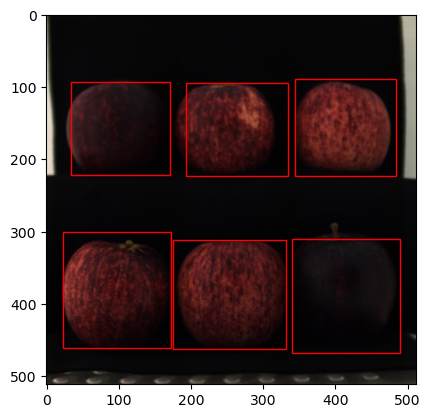

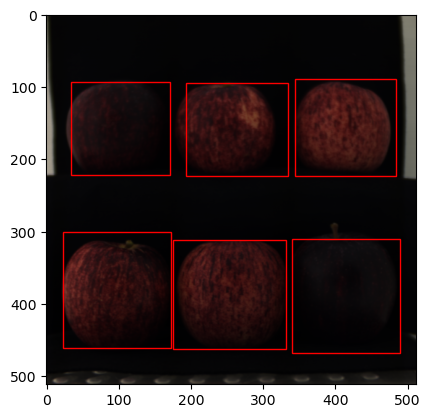

In [110]:
rgb_image = utils.read_image('/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/20240307 Gala/2024-03-07_001/2024-03-07_001.png')
show_labeled_image(rgb_image, test_data['test_tensor'].iloc[0])
# print(test_data['test_tensor'].iloc[0])

file_path = '/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/'
dat_files = "/media/2tbdisk2/data/Haidee_apple_data/Haidee/Hyperspectral_images/spectral_NZ_2024/20240307 Gala/2024-03-07_001/results/REFLECTANCE_2024-03-07_001.dat"

spectral_data = np.fromfile(dat_files, dtype=np.float32)
bands = len(spectral_data) // (height * width)
spectral_data = spectral_data.reshape(height, bands, width)
spectral_data = np.transpose(spectral_data, (2, 0, 1))  # Convert to (H, W, B)
# reconstruct RGB image from hyperspectral data
spectral_data = spectral_data.astype(np.float32) / 65535.0
spectral_data = (spectral_data - spectral_data.min()) / (spectral_data.max() - spectral_data.min())
# print(f'Max value: {np.max(spectral_data)}, Min value: {np.min(spectral_data)}')
red_band = spectral_data[:, :, 70] # the channel that is red
green_band = spectral_data[:, :, 53] # the channel that is green
blue_band = spectral_data[:, :, 19] # the channel that is blue
reconstructed_rgb_img = np.stack([red_band, green_band, blue_band], axis=-1)

reconstructed_rgb_img_flipped = np.fliplr(reconstructed_rgb_img)

show_labeled_image(reconstructed_rgb_img_flipped, test_data['test_tensor'].iloc[0])

        # Display image
        # plt.imshow(rgb_image)
        # plt.axis("off")
        # plt.title("RGB Composite from Hyperspectral Data extracted from tensor")
        # plt.show()

        # Find tensors and sort from reconstructed RGB image



In [ ]:
NZ2023_loc_link = 'spectral_NZ_2023'
NZ2024_loc_link = 'spectral_NZ_2024'
UK2024_loc_link = 'spectral_UK_2024'

data_NZ2023_a_na['sorted_tensor'] = data_NZ2023_a_na['Spectral_folder_a'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_b_na['sorted_tensor'] = data_NZ2023_b_na['Spectral_folder_b'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_c_na['sorted_tensor'] = data_NZ2023_c_na['Spectral_folder_c'].apply(lambda x: extractor(x, model2, NZ2023_loc_link)) 
data_NZ2023_d_na['sorted_tensor'] = data_NZ2023_d_na['Spectral_folder_d'].apply(lambda x: extractor(x, model2, NZ2023_loc_link))
data_NZ2023_a_na['sorted_tensor'].head(5)

data_NZ2024_a_na['sorted_tensor'] = data_NZ2024_a_na['Spectral_folder_a'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_b_na['sorted_tensor'] = data_NZ2024_b_na['Spectral_folder_b'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_c_na['sorted_tensor'] = data_NZ2024_c_na['Spectral_folder_c'].apply(lambda x: extractor(x, model2, NZ2024_loc_link)) 
data_NZ2024_d_na['sorted_tensor'] = data_NZ2024_d_na['Spectral_folder_d'].apply(lambda x: extractor(x, model2, NZ2024_loc_link))
data_NZ2024_a_na['sorted_tensor'].head(5)



data_UK2024_a_na['sorted_tensor'] = data_UK2024_a_na['Spectral_folder_a'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_b_na['sorted_tensor'] = data_UK2024_b_na['Spectral_folder_b'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_c_na['sorted_tensor'] = data_UK2024_c_na['Spectral_folder_c'].apply(lambda x: extractor(x, model2, UK2024_loc_link)) 
data_UK2024_d_na['sorted_tensor'] = data_UK2024_d_na['Spectral_folder_d'].apply(lambda x: extractor(x, model2, UK2024_loc_link))
data_UK2024_a_na['sorted_tensor'].head(5)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121


KeyboardInterrupt: 

In [ ]:
def lengther(data):
    return len(data)

In [ ]:
# Get count of apples detected from each png file

# data_test['number_of_apples'] = data_test['sorted_tensor'].apply(lambda x: lengther(x))

data_NZ2023_a_na['number_of_apples'] = data_NZ2023_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_b_na['number_of_apples'] = data_NZ2023_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_c_na['number_of_apples'] = data_NZ2023_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2023_d_na['number_of_apples'] = data_NZ2023_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_NZ2023_a_na.head(n=5))

data_NZ2024_a_na['number_of_apples'] = data_NZ2024_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_b_na['number_of_apples'] = data_NZ2024_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_c_na['number_of_apples'] = data_NZ2024_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_NZ2024_d_na['number_of_apples'] = data_NZ2024_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_NZ2024_a_na.head(n=5))

data_UK2024_a_na['number_of_apples'] = data_UK2024_a_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_b_na['number_of_apples'] = data_UK2024_b_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_c_na['number_of_apples'] = data_UK2024_c_na['sorted_tensor'].apply(lambda x: lengther(x))
data_UK2024_d_na['number_of_apples'] = data_UK2024_d_na['sorted_tensor'].apply(lambda x: lengther(x))
print(data_UK2024_a_na.head(n=5))

                                      Image_folder_A    image_filename_A  \
0  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
1  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
2  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
3  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   
4  20230328 Fuji PFR orchard early pick/2023-03-2...  2023-03-28_002.png   

       ID  Number  Firmness1  Firmness2   Brix  Starch  Starch2    Streif  \
0  Fuji_1     1.0       6.38       6.23  12.43    50.0      8.0  4.057924   
1  Fuji_2     2.0       7.32       8.84  14.04    43.0      8.0  4.603989   
2  Fuji_3     3.0       8.02       8.86  11.53    80.0      4.0  2.928014   
3  Fuji_4     4.0       6.36       7.82  12.18    63.0      7.0  4.074713   
4  Fuji_5     5.0       8.13       7.38  12.10    45.0      8.0  5.127273   

   Avg_firmness Cultivar                                      sorted_tensor  \
0

In [ ]:
# Check each harvest_data for number of apples expected in an image and checking there is the same number in the image folder
# 'number_of_apples' is the number of apples from the same image folder 
# 'Count' is the number of apples found using the map function within the image

# name_counts_test = data_test['Image_folder_A'].value_counts()
# # Create a new column with the counts
# data_test['Count'] = data_test['Image_folder_A'].map(name_counts_test)
# indices_test_a = np.where(data_test['Count'].values != data_test['number_of_apples'].values)[0]
# # Print the indices
# print(indices_test_a)
# print(len(indices_test_a))
# missing_img_NZ2023_a = [] 
# for i in indices_test_a:
#     missing_img_NZ2023_a.append(data_test['Image_folder_A'].iloc[i])


name_counts_NZ2023 = data_NZ2023_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_NZ2023_a_na['Count'] = data_NZ2023_a_na['Image_folder_A'].map(name_counts_NZ2023)
indices_NZ2023_a = np.where(data_NZ2023_a_na['Count'].values != data_NZ2023_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2023_a)
print(len(indices_NZ2023_a))
missing_img_NZ2023_a = [] 
for i in indices_NZ2023_a:
    missing_img_NZ2023_a.append(data_NZ2023_a_na['Image_folder_A'].iloc[i])




name_counts_NZ2024 = data_NZ2024_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_NZ2024_a_na['Count'] = data_NZ2024_a_na['Image_folder_A'].map(name_counts_NZ2024)
indices_NZ2024_a = np.where(data_NZ2024_a_na['Count'].values != data_NZ2024_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_NZ2024_a)
print(len(indices_NZ2024_a))
missing_img_NZ2024_a = [] 
for i in indices_NZ2024_a:
    missing_img_NZ2024_a.append(data_NZ2024_a_na['Image_folder_A'].iloc[i])




name_counts_UK2024= data_UK2024_a_na['Image_folder_A'].value_counts()
# Create a new column with the counts
data_UK2024_a_na['Count'] = data_UK2024_a_na['Image_folder_A'].map(name_counts_UK2024)
indices_UK2024_a = np.where(data_UK2024_a_na['Count'].values != data_UK2024_a_na['number_of_apples'].values)[0]
# Print the indices
print(indices_UK2024_a)
print(len(indices_UK2024_a))
missing_img_UK2024_a = [] 
for i in indices_UK2024_a:
    missing_img_UK2024_a.append(data_UK2024_a_na['Image_folder_A'].iloc[i])

[ 929  930  931  932  933  934  935 1142]
8
[296 297 298 299 300 301 302 303 304 305 334 335 336 337 338 339 633 634
 635 636 637 638 663 664 665 666 667 668 771 772 773 774 775 776 777 778
 779 780 781 782 783 784 785 786 787 788 815 816 817 818 819 820 821 822
 823 824 825 826 827 828 829 830 831 832 940 941 942 943 944]
69
[  10   11   12   13   14   15   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   97   98   99  100  101  102  103  118  119  120  121  122
  123  124  125  126  127  128  129  130  131  139  140  141  142  143
  144  145  146  147  148  149  150  151  152  160  161  162  163  164
  165  166  167  168  169  170  171  172  173  202  203  204  205  206
  207  208  447  448  449  450  451  452  453  454  455  456  457  458
  459  460  601  602  603  604  605  606  607  689  690  691  692  978
  979  980  981  982  983  984  985  993  994  995  996  997  998 1752
 1753 1754 1755 1756 1757 1758 17